## Regularization
- ### Lasso Regression (L1 Rgularization)
- ### Ridge Regression (L2 Regularization)
- ### ElasticNet 

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

X.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [2]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [3]:
X.isna().sum()


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'R2 Score: {r2}')

MSE: 0.5558915986952442
R2 Score: 0.575787706032451


### Lasso Regression

In [6]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f'Lasso MSE: {mse_lasso}')
print(f'Lasso R2 Score: {r2_lasso}')

Lasso MSE: 0.6135115198058129
Lasso R2 Score: 0.5318167610318161


In [17]:
alphas = [0.01, 0.1, 1, 10, 100]
mses = []
for alpha in alphas:

    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)

    y_pred_lasso = lasso.predict(X_test)

    mse_lasso = mean_squared_error(y_test, y_pred_lasso)
    r2_lasso = r2_score(y_test, y_pred_lasso)

    print(f'Lasso (alpha={alpha}) MSE: {mse_lasso}')
    print(f'Lasso (alpha={alpha}) R2 Score: {r2_lasso}')
    mses.append(mse_lasso)



Lasso (alpha=0.01) MSE: 0.544449158124652
Lasso (alpha=0.01) R2 Score: 0.5845196673976367
Lasso (alpha=0.1) MSE: 0.6135115198058129
Lasso (alpha=0.1) R2 Score: 0.5318167610318161
Lasso (alpha=1) MSE: 0.9380337514945428
Lasso (alpha=1) R2 Score: 0.2841671821008396
Lasso (alpha=10) MSE: 1.3102267608225504
Lasso (alpha=10) R2 Score: 0.00013905385370127643
Lasso (alpha=100) MSE: 1.3106960720039365
Lasso (alpha=100) R2 Score: -0.00021908714592466794


Text(0, 0.5, 'Mean Squared Error')

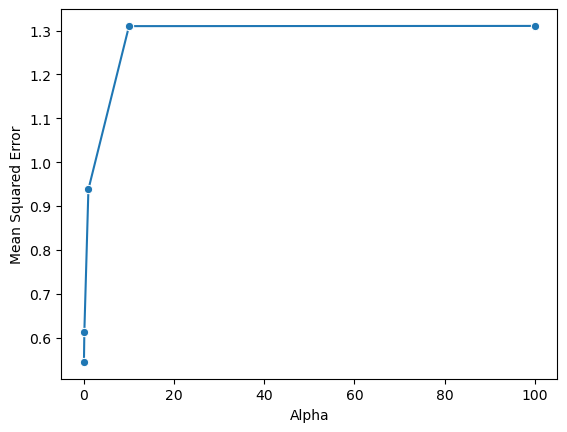

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=alphas, y=mses, marker='o')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')

### Using Cross vlidation instead of looping

### using LassoCV

In [19]:
from sklearn.linear_model import LassoCV
lasso_cv_model = LassoCV(
    alphas=alphas,
    random_state=42,
    cv=5, # 5-fold cross-validation
    max_iter=1000
)

lasso_cv_model.fit(X_train, y_train)

print(f'Best alpha: {lasso_cv_model.alpha_}')

Best alpha: 0.01


In [16]:
y_pred_lasso_cv = lasso_cv_model.predict(X_test)

mse_lasso_cv = mean_squared_error(y_test, y_pred_lasso_cv)
r2_lasso_cv = r2_score(y_test, y_pred_lasso_cv)

print(f'LassoCV MSE: {mse_lasso_cv}')
print(f'LassoCV R2 Score: {r2_lasso_cv}')

LassoCV MSE: 0.544449158124652
LassoCV R2 Score: 0.5845196673976367


### Ridge Regression

In [20]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f'Ridge MSE: {mse_ridge}')
print(f'Ridge R2 Score: {r2_ridge}')

Ridge MSE: 0.5558034669932211
Ridge R2 Score: 0.5758549611440126


#### using RidgeCV

In [ ]:
from sklearn.linear_model import RidgeCV
ridge_cv_model = RidgeCV(
    alphas=alphas,
    cv=5,
)

ridge_cv_model.fit(X_train, y_train)

print(f'Best alpha: {ridge_cv_model.alpha_}')



Best alpha: 10.0


In [25]:
y_pred_ridge_cv = ridge_cv_model.predict(X_test)

mse_ridge_cv = mean_squared_error(y_test, y_pred_ridge_cv)
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)

print(f'RidgeCV MSE: {mse_ridge_cv}')
print(f'RidgeCV R2 Score: {r2_ridge_cv}')

RidgeCV MSE: 0.5550405537343012
RidgeCV R2 Score: 0.5764371559180015


### Elastic Net

In [26]:
from sklearn.linear_model import ElasticNet

elastic_net_model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5 # 50% L1 regularization, 50% L2 regularization
)

elastic_net_model.fit(X_train, y_train)

y_pred_elastic_net = elastic_net_model.predict(X_test)

mse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net)
r2_elastic_net = r2_score(y_test, y_pred_elastic_net)

print(f'ElasticNet MSE: {mse_elastic_net}')
print(f'ElasticNet R2 Score: {r2_elastic_net}')

ElasticNet MSE: 0.5730994198028208
ElasticNet R2 Score: 0.5626560643897964


In [27]:
from sklearn.linear_model import ElasticNetCV

elastic_net_cv_model = ElasticNetCV(
    alphas= alphas,
    l1_ratio=0.5,
    cv=5
)

elastic_net_cv_model.fit(X_train, y_train)

y_pred_elastic_net_cv = elastic_net_cv_model.predict(X_test)

mse_elastic_net_cv = mean_squared_error(y_test, y_pred_elastic_net_cv)
r2_elastic_net_cv = r2_score(y_test, y_pred_elastic_net_cv)

print(f'ElasticNetCV MSE: {mse_elastic_net_cv}')
print(f'ElasticNetCV R2 Score: {r2_elastic_net_cv}')

ElasticNetCV MSE: 0.5456722465265749
ElasticNetCV R2 Score: 0.5835863035225168
